# Data Pipeline — Sanity Check

Visual verification that the data pipeline (`data/preprocessing/data_pipeline.py`) is
working correctly. Plots three spectrograms — training (SpecAugment masks visible),
validation (no augmentation), and a multi-label soundscape sample — to confirm:

1. Spectrogram shape is `(1, 128, 313)` — correct mel params
2. SpecAugment is applied to training samples only
3. Multi-label soundscape samples load and encode correctly

**Note:** This notebook imports directly from `data_pipeline.py`. It does not
duplicate pipeline code. Set `$DATA_ROOT` to your data directory before running.

In [14]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt

# Allow import from repo root regardless of working directory
_repo_root = Path().resolve()
if (_repo_root / "data" / "preprocessing" / "data_pipeline.py").exists():
    pass  # already at repo root
else:
    _repo_root = _repo_root.parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from preprocessing.data_pipeline import build_dataloaders  # noqa: E402

DATA_ROOT = Path(
    os.environ.get("DATA_ROOT")
    or os.environ.get("BIRDCLEF_DATA_ROOT")
    or "/tmp/birdclef-2026"
)
assert DATA_ROOT.exists(), f"DATA_ROOT not found: {DATA_ROOT}. Set $DATA_ROOT."

train_loader, val_loader, _test_loader, mlb = build_dataloaders(
    metadata_csv=str(DATA_ROOT / "train.csv"),
    audio_dir=str(DATA_ROOT / "train_audio"),
    soundscapes_dir=str(DATA_ROOT / "train_soundscapes"),
    soundscapes_csv=str(DATA_ROOT / "train_soundscapes_labels.csv"),
    val_size=0.15,
    test_size=0.15,
    batch_size=8,
    num_workers=2,
)

train_audio — recordings: 35549, species: 206
Singleton classes moved to train only: 4 recordings, 4 species
Split — train: 24885 (70%), val: 5332 (15%), test: 5332 (15%)  [seed=42]
Number of classes K: 206
[train] duration cache: 15709 existing entries in /home/renku/work/aml2026-group-10/.cache/birdclef/train_audio_durations.json


/layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[train] duration cache: 40594 total entries  (hits=0, misses=24885)  -> /home/renku/work/aml2026-group-10/.cache/birdclef/train_audio_durations.json
[val] duration cache: 40594 existing entries in /home/renku/work/aml2026-group-10/.cache/birdclef/train_audio_durations.json
[val] duration cache: 45926 total entries  (hits=0, misses=5332)  -> /home/renku/work/aml2026-group-10/.cache/birdclef/train_audio_durations.json
[test] duration cache: 45926 existing entries in /home/renku/work/aml2026-group-10/.cache/birdclef/train_audio_durations.json
[test] duration cache: 51258 total entries  (hits=0, misses=5332)  -> /home/renku/work/aml2026-group-10/.cache/birdclef/train_audio_durations.json
Training samples  — audio chunks: 161651, soundscape segments: 1478, total: 163129
Validation samples: 36331
Test samples      : 35119


/layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Train spec shape  : torch.Size([8, 1, 128, 313])
Label vector shape: torch.Size([8, 206])
Label sums        : [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

── Check 2: Validation batch ────────────────────────────────────────
Spectrogram shape : torch.Size([8, 1, 128, 313])
Label vector shape: torch.Size([8, 206])
Label sums        : tensor([1., 1., 1., 1., 1., 1., 1., 1.])

── Check 3: Multi-label soundscape sample ───────────────────────────
Found at index    : 161651
Raw labels        : ['22961', '23158', '24321', '517063', '65380']
Encoded labels    : ['22961' '23158' '24321' '65380']
Label vector sum  : 4.0


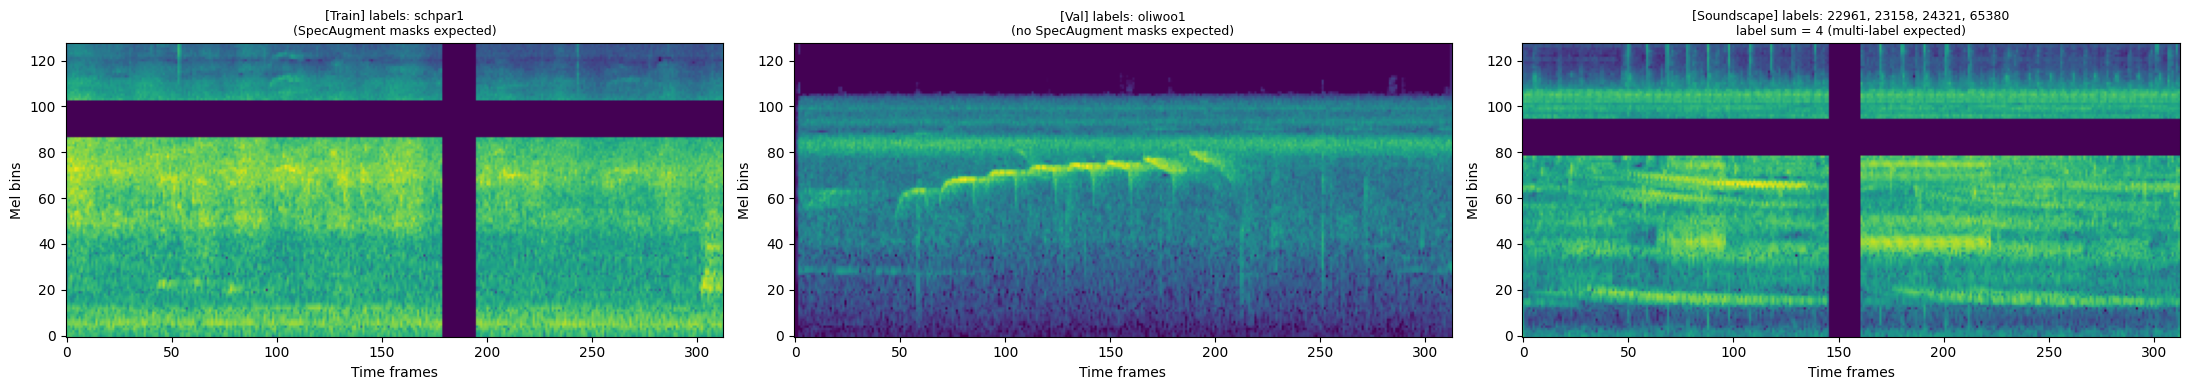

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(22, 4))

# ── Check 1: Training spectrogram (SpecAugment masks expected) ──────────────
train_specs, train_labels = next(iter(train_loader))
print(f"Train spec shape  : {train_specs.shape}")   # (8, 1, 128, 313)
print(f"Label vector shape: {train_labels.shape}")  # (8, K)
print(f"Label sums        : {train_labels.sum(dim=1).tolist()}")

ax = axes[0]
ax.imshow(train_specs[0, 0].numpy(), aspect='auto', origin='lower', cmap='viridis')
active = mlb.classes_[train_labels[0].bool().numpy()]
ax.set_title(f"[Train] labels: {', '.join(active)}\n"
             f"(SpecAugment masks expected)", fontsize=9)
ax.set_xlabel("Time frames"); ax.set_ylabel("Mel bins")


print("\n── Check 2: Validation batch ────────────────────────────────────────")
val_specs, val_labels = next(iter(val_loader))
print(f"Spectrogram shape : {val_specs.shape}")
print(f"Label vector shape: {val_labels.shape}")
print(f"Label sums        : {val_labels.sum(dim=1)}")   # all 1 (single-label)

ax = axes[1]
ax.imshow(val_specs[0, 0].numpy(), aspect='auto', origin='lower', cmap='viridis')
active_val = mlb.classes_[val_labels[0].bool().numpy()]
ax.set_title(f"[Val] labels: {', '.join(active_val)}\n"
             f"(no SpecAugment masks expected)", fontsize=9)
ax.set_xlabel("Time frames"); ax.set_ylabel("Mel bins")

print("\n── Check 3: Multi-label soundscape sample ───────────────────────────")
multi_label_idx = None
for i, sample in enumerate(train_loader.dataset.samples):
    if len(sample['labels']) > 1:
        multi_label_idx = i
        break

if multi_label_idx is not None:
    spec_ml, label_ml = train_loader.dataset[multi_label_idx]
    sample_ml         = train_loader.dataset.samples[multi_label_idx]
    active_ml         = mlb.classes_[label_ml.bool().numpy()]
    print(f"Found at index    : {multi_label_idx}")
    print(f"Raw labels        : {sample_ml['labels']}")
    print(f"Encoded labels    : {active_ml}")
    print(f"Label vector sum  : {label_ml.sum()}")  # should be > 1

    ax = axes[2]
    ax.imshow(spec_ml[0].numpy(), aspect='auto', origin='lower', cmap='viridis')
    ax.set_title(f"[Soundscape] labels: {', '.join(active_ml)}\n"
                 f"label sum = {int(label_ml.sum())} (multi-label expected)", fontsize=9)
    ax.set_xlabel("Time frames"); ax.set_ylabel("Mel bins")
else:
    print("No multi-label soundscape sample found — check soundscapes CSV loading.")
    axes[2].set_title("[Soundscape] — no multi-label sample found")
    axes[2].axis('off')

plt.tight_layout()
plt.show()

The spectrogram visualizations provide an important qualitative validation of both the preprocessing pipeline and the augmentation strategy used during training. Each audio clip is transformed into a log-scaled mel spectrogram of shape (128 $\times$ 313), where the vertical axis represents mel-frequency bins and the horizontal axis represents time frames over a 5-second audio segment. The resulting representation exposes characteristic bird vocalization structures such as harmonics, frequency sweeps, chirps, and temporal repetition patterns, which are well suited for convolutional and Transformer-based architectures.

A key aspect of the training pipeline is the use of *SpecAugment*, a spectrogram-domain data augmentation technique applied exclusively during training. The motivation for SpecAugment is to improve generalization under the substantial domain gap between the training recordings and the target soundscape environment. The training clips are generally clean and dominated by a single foreground species, whereas real-world soundscapes contain overlapping vocalizations, environmental noise, partial occlusions, and intermittent signal corruption. Without augmentation, the model risks overfitting to highly clean acoustic patterns that may not generalize well to noisy passive acoustic monitoring data.

To mitigate this issue, two SpecAugment operations are applied sequentially during training:

* **Frequency masking** (`FrequencyMasking(freq_mask_param=24)`): randomly removes up to 24 consecutive mel-frequency bins. This prevents the model from relying excessively on any single narrow frequency region and encourages robustness to frequency-localized noise or recording artifacts.

* **Time masking** (`TimeMasking(time_mask_param=64)`): randomly removes up to 64 consecutive time frames. This simulates interruptions, partial occlusions, or missing call segments frequently encountered in real soundscapes.

These augmentations are clearly visible in the training spectrogram example. The large vertical dark region corresponds to time masking, while the horizontal dark band near the top of the spectrogram corresponds to frequency masking. Their simultaneous presence is expected because both augmentations are applied independently during the same training step. Since the masks are sampled randomly at every iteration, the model observes a slightly different version of each spectrogram during every epoch, effectively increasing data diversity without requiring additional recordings.

The comparison between the training and validation spectrograms further confirms that augmentation is only applied during training. The validation spectrogram remains fully intact, allowing evaluation on unmodified data and ensuring that validation metrics reflect true model performance rather than robustness to artificially corrupted inputs.

The final spectrogram example illustrates a multi-label soundscape sample containing several simultaneously active species. Unlike the single-species training clips, this sample contains overlapping acoustic events from multiple birds, which more closely resembles the conditions encountered during inference in the BirdCLEF task. The associated label vector therefore contains multiple active entries, resulting in a label sum greater than one. By contrast, the standard training and validation batches each contain exactly one active label per sample, reflecting the single-species nature of the Xeno-canto recordings. This highlights an important characteristic of the task: although the problem is formulated as multi-label classification, much of the training data consists of single-label examples, while true multi-label behavior emerges primarily during soundscape inference.
